In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/DL/')

# Unzip

In [ ]:
#import shutil to handle file so they can unzip the file
import shutil
#unzip the dataset and put the zip file into rhe file called Dataset
shutil.unpack_archive('/content/drive/MyDrive/DL/dataset2-master.zip', '/content/drive/MyDrive/DL/Dataset')

# Import Libraries

In [ ]:
#clone the d2l pytorch from the github
!git clone https://github.com/d2l-ai/d2l-pytorch-colab.git
#will change directory to the clone repository
%cd 'd2l-pytorch-colab'
# instaill the d2l in editable mode
!pip install -e

Cloning into 'd2l-pytorch-colab'...
remote: Enumerating objects: 10698, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 10698 (delta 91), reused 84 (delta 84), pack-reused 10588 (from 2)
Receiving objects: 100% (10698/10698), 211.37 MiB | 17.73 MiB/s, done.
Resolving deltas: 100% (8494/8494), done.
/content/d2l-pytorch-colab

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

-e option requires 1 argument


In [ ]:
#import d2l pytorch
from d2l import torch as d2l

In [ ]:

# load main library pytorch
import torch
#import neural network
import torch.nn as nn
#so optimizer so like adam and this use for model weight
import torch.optim as optim
#more neural network being import
import torch.nn.functional as F

# so the Dara and image transformation from the torchvision
from torchvision import datasets, transforms, models
# import efficientnet-B3 model and its pretrained weight
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
#import dataloader to be able to load data in batches
from torch.utils.data import DataLoader
#import randin
import random
#import time
import time
#import numpy for numerical operation and array
import numpy as np
#import pandas so to handling dataset and table
import pandas as pd
#import statistic function from the scipy
from scipy import stats
#import matplotlib this is for plotting graph
import matplotlib.pyplot as plt
#this import allow to get better desgin graph
import seaborn as sns
# import PIL that stand for python image library to load and also process image
from PIL import Image
#import tqdm to show projress bar in training
from tqdm import tqdm
# import sklearn so scikit-learn to able to do evaluation metric
# Create the confusion matrix and also display confusion matrix
# measures precision and recall and F1 and ROC-AUC
# Full classification report
# create ROC curve
# calculates area under curve
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc
)
#Import label binarization form sklearn use it for ROC/AUC
from sklearn.preprocessing import label_binarize
#PyTorch that let me take only part of my dataset
from torch.utils.data import Subset


# Dataset Preparation and Data Cleaning

In [ ]:

#these dataset show where being store
train_dir = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/TRAIN"
test_dir  = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/TEST"
val_dir   = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/VAL"
#them these print function are show me that they store correctly
#val_dir or test_dir or train_ dir mean directory
print("TRAIN DIR:", train_dir)
print("TEST DIR :", test_dir)
print("VAL DIR  :", val_dir)

# create new folder call VAL off course it not already exist
os.makedirs(val_dir, exist_ok=True)



TRAIN DIR: /content/drive/MyDrive/DL/Dataset/dataset2-master/images/TRAIN
TEST DIR : /content/drive/MyDrive/DL/Dataset/dataset2-master/images/TEST
VAL DIR  : /content/drive/MyDrive/DL/Dataset/dataset2-master/images/VAL


In [ ]:
# this function will find all the class name inside the train file
classes = sorted(os.listdir(train_dir))
#show all the class that in the train dataset and also how many are there
print("\nDetected Classes:", classes)
print("Number of classes:", len(classes))



Detected Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Number of classes: 4


In [ ]:

#moveing 20% of the train dataset image into new fold call VAL file
for cls in classes:
  # so it will go to file with class that in the train dataset
    cls_train_path = os.path.join(train_dir, cls)
    #creates a separate class folder inside the VAL folder
    cls_val_path   = os.path.join(val_dir, cls)

    #then create new class file that inside the VAl just in case if they are not already there
    os.makedirs(cls_val_path, exist_ok=True)

    # looking at each class folder and get ther name of image
    images = os.listdir(cls_train_path)
    #shufflle image randomly
    random.shuffle(images)

    # calculate how many image shou;d go to val so for me 0.2 so 20 percentage
    split_idx = int(0.2 * len(images))
    # take first 20% image
    val_images = images[:split_idx]

    # move the image from the train to Val
    for img in val_images:
        shutil.move(
            os.path.join(cls_train_path, img),#source path so where image came from
            os.path.join(cls_val_path, img)# to plce where  the image wil be store
        )
#print how many image was move in per class
    print(f"{cls}: moved {len(val_images)} images to VAL folder")

print("\nValidation split completed successfully!")


EOSINOPHIL: moved 499 images to VAL folder
LYMPHOCYTE: moved 496 images to VAL folder
MONOCYTE: moved 495 images to VAL folder
NEUTROPHIL: moved 499 images to VAL folder

Validation split completed successfully!


In [ ]:


def clean_bad_images(directories):
    total_checked = 0# count all the image
    total_deleted = 0# count all image that delete image
    deleted_files = []#stor name of delete file
# go through each main folder so the train and test and val
    for root_dir in directories:
      #print the name of the folder that being currently being check
        print(f"\nScanning: {root_dir}")
        #check every folder inside file
        for root, _, files in os.walk(root_dir):
          # root =  current file path
          #_ = file inside the path
          # go through each file in the current folder
            for file in files:
              #check only image that only have the following .jpg, .jpeg, .png
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                  #create the full path of the image file
                    path = os.path.join(root, file)
                   #increase the count of the check image by one every
                    total_checked += 1

                    try:
                      # try to open the image file
                        with Image.open(path) as img:
                          # see if the image is not broken
                            img.verify()

                    except Exception:
                      #if the image is broken then delete the file
                        os.remove(path)
                        #so increase the count od the delete imnage by one
                        total_deleted += 1
                        #then save the name of the delete file
                        deleted_files.append(path)

#print final result
    print("\n CLEANUP SUMMARY ")
    print(f"Checked images: {total_checked}")
    print(f"Deleted corrupted images: {total_deleted}")

    # Show names of deleted files
    if deleted_files:
        print("\nDeleted files:")
        for f in deleted_files:
            print(f)

# Your dataset paths
train_dir = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/TRAIN"
test_dir  = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/TEST"
val_dir   = "/content/drive/MyDrive/DL/Dataset/dataset2-master/images/VAL"

# Check and remove corrupted images
clean_bad_images([train_dir, test_dir, val_dir])



Scanning: /content/drive/MyDrive/DL/Dataset/dataset2-master/images/TRAIN

Scanning: /content/drive/MyDrive/DL/Dataset/dataset2-master/images/TEST

Scanning: /content/drive/MyDrive/DL/Dataset/dataset2-master/images/VAL

 CLEANUP SUMMARY 
Checked images: 12444
Deleted corrupted images: 0


# Data Analysis

In [ ]:
# Count number of images per class
def count_images(directory, classes):
    counts = {}# create an empty dictionary to store number of images per class
    for cls in classes:#loop through
        cls_path = os.path.join(directory, cls)  # path to this class
        if not os.path.exists(cls_path): #check if the file exist
            counts[cls] = 0  # if folder doesn't exist set count to 0
        else:
            # count image that only have .png, .jpg, .jpeg files
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return counts #return the directionary with counts

# Count images in each set
train_counts = count_images(train_dir, classes) # counts per class in set
val_counts   = count_images(val_dir, classes) # counts per class in set
test_counts  = count_images(test_dir, classes) # counts per class in set

# calculate total images per class
total_counts = {
    cls: train_counts[cls] + val_counts[cls] + test_counts[cls]
    for cls in classes
}

# 5️⃣ calculate percentage of each set per class
train_percent = {
    cls: (train_counts[cls] / total_counts[cls]) * 100 if total_counts[cls] > 0 else 0
    for cls in classes
    #Train = (Train_images / Total_images_per_class) * 100

}
val_percent = {
    cls: (val_counts[cls] / total_counts[cls]) * 100 if total_counts[cls] > 0 else 0
    for cls in classes
    #Val = (Val_images / Total_images_per_class) * 100

}
test_percent = {
    cls: (test_counts[cls] / total_counts[cls]) * 100 if total_counts[cls] > 0 else 0
    for cls in classes
    #Test = (Test_images / Total_images_per_class) * 100

}

# calculate of total images in dataset per class
total_percent = {
    cls: (total_counts[cls] / sum(total_counts.values())) * 100
    for cls in classes
    #Total = (Total_images_per_class / Sum_of_all_classes_total_images) * 100


}

# build a DataFrame to display counts and percentages
df_counts = pd.DataFrame({
    'Train': train_counts,
    'Train %': train_percent,
    'Val': val_counts,
    'Val %': val_percent,
    'Test': test_counts,
    'Test %': test_percent,
    'Total': total_counts,
    'Total %': total_percent
})

#  percentage columns to 2 decimal points
for col in ['Train %', 'Val %', 'Test %', 'Total %']:
    df_counts[col] = df_counts[col].apply(lambda x: f"{x:.2f}%")

# Show the table
print("Image Counts (Train/Val/Test/Total) with Percentages:")
print(df_counts)


Image Counts (Train/Val/Test/Total) with Percentages:
            Train Train %  Val   Val %  Test  Test %  Total Total %
EOSINOPHIL   1998  64.04%  499  15.99%   623  19.97%   3120  25.07%
LYMPHOCYTE   1987  64.03%  496  15.98%   620  19.98%   3103  24.94%
MONOCYTE     1983  64.01%  495  15.98%   620  20.01%   3098  24.90%
NEUTROPHIL   2000  64.04%  499  15.98%   624  19.98%   3123  25.10%


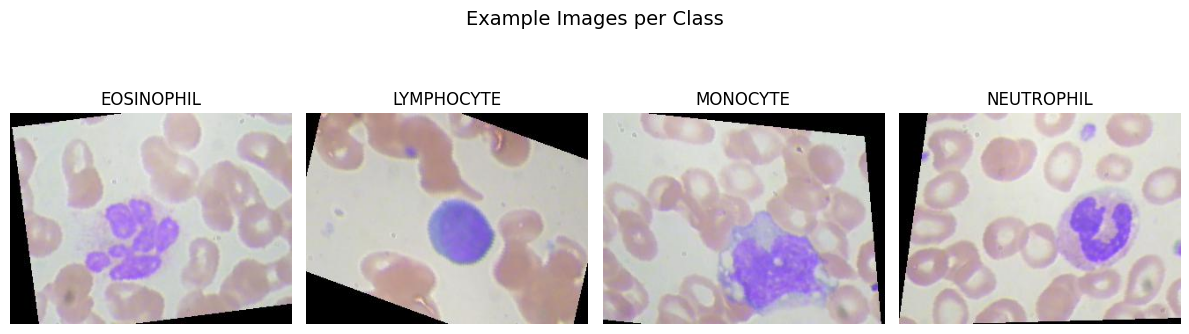

In [ ]:
#  Display Example Images per Class
#create the figure with 1 row and as many columns need for the class
# size of the figure is 12,4 so mean the width is 12 and 4 in height
fig, axes = plt.subplots(1, len(classes), figsize=(12, 4))
#loop throught each class
for i, cls in enumerate(classes):
  #pick the first image from each class file
  # os.listdir() lists all files
   #[0] selects the first one
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
   #open the image using PIL
    img = Image.open(img_path)
   #show image in the subplot for this class
    axes[i].imshow(img)
   #set the title od this subplor to the clas name
    axes[i].set_title(cls)
    #  Remove the axis ticks for a cleaner look
    axes[i].axis('off')
#Add a main title
plt.suptitle("Example Images per Class", fontsize=14)
# Automatically adjust spacing so titles and images don't overlap
plt.tight_layout()
#Display the figure
plt.show()




In [ ]:
#  Check Image Sizes and Dimensions
sizes = []#creare empyy list to store image size
for cls in classes:# loop through each class
# Pick the first file as a sample image
   # os.listdir() lists all files
   #[0] selects the first one
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    #open the image using PIL
    img = Image.open(img_path)
    #get the image sixe and add it to the list
    sizes.append(img.size)
# create a dataframe to display image size
df_sizes = pd.DataFrame(sizes, index=classes, columns=['Width', 'Height'])
# Print the DataFrame
print("\nAverage Image Sizes by Class:\n", df_sizes)





Average Image Sizes by Class:
             Width  Height
EOSINOPHIL    320     240
LYMPHOCYTE    320     240
MONOCYTE      320     240
NEUTROPHIL    320     240


In [ ]:
# Compute Color Channel Statistics (Mean & Std)
def compute_image_stats(folder):
  #list to store mean and std value od each image
    means, stds = [], []
    #Loop through each class folder
    for cls in classes:
        cls_path = os.path.join(folder, cls)# path to current class folder
        for img_file in os.listdir(cls_path)[:100]:  # sample 100 per class for speed
        #open images and convert them to numpy array and normalize to 0-1 range
        #calculate img_normalized = imag_array/255
            img = np.array(Image.open(os.path.join(cls_path, img_file))) / 255.0
         #calculate mean per channel (R,G,B)
         #calculate Mean = sum(all_pixel_values_per_channel) / number_of_pixels
            means.append(img.mean(axis=(0,1)))
             #calculate standard deviation per channel (R,G,B)
         #calculate std_rgb = sqrt(sum((pixel_value - mean)^2) / number_of_pixels)
            stds.append(img.std(axis=(0,1)))
            #calculate average of all image means and stds across classes
    # calculate mean_rgb_dataset = sum(mean_rgb_of_each_image) / number_of_images
    #std_rgb_dataset  = sum(std_rgb_of_each_image) / number_of_images

    return np.mean(means, axis=0), np.mean(stds, axis=0)
# Call the function on the train folder

mean_rgb, std_rgb = compute_image_stats(train_dir)
# Display results

print("Color Channel Statistics:")
print("Mean RGB values:", np.round(mean_rgb, 4))
print("Std RGB values:", np.round(std_rgb, 4))


Color Channel Statistics:
Mean RGB values: [0.6811 0.6437 0.6641]
Std RGB values: [0.2583 0.2581 0.2553]


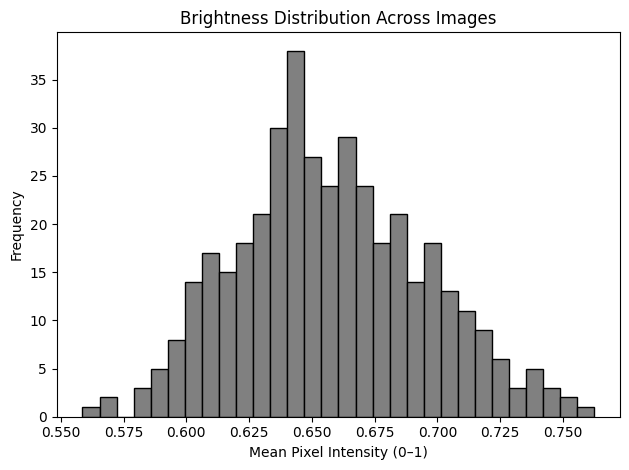

In [ ]:
#Brightness / Intensity Distribution
#list to store brightnes value of image
brightness = []
#loop through each class
for cls in classes:
  #loop through the first 100 image in each class
    for img_file in os.listdir(os.path.join(train_dir, cls))[:100]:
   #open the image and convert it to grey scale and then convert the image into  numpy array
   #calculate os img_normalized = img_array / 255 and then Convert to grayscale simplifies brightness calculation
        img = np.array(Image.open(os.path.join(train_dir, cls, img_file)).convert("L")) / 255.0
    #L mean Convert this image to grayscale
        brightness.append(img.mean())
    # calculate mean brightness of the image
    # calculate brightness_image = sum(all_pixel_values) / number_of_pixels
  # Plot histogram of brightness values
plt.hist(brightness, bins=30, color='gray', edgecolor='black')
# Add title and axis labels
plt.title("Brightness Distribution Across Images")
plt.xlabel("Mean Pixel Intensity (0–1)")
plt.ylabel("Frequency")
# Adjust layout to avoid overlapping
plt.tight_layout()
# Show the plot

plt.show()



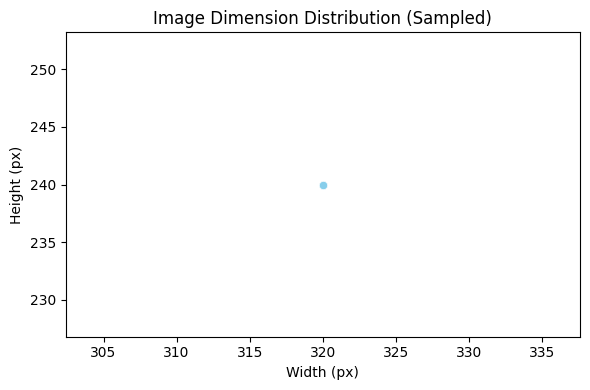


Average image size: 320.0 x 240.0 pixels


In [ ]:
# Detect Potential Outliers

image_shapes = []
# Create  list to store image sizes

for cls in classes:
    # Loop through each class name

    for img_file in os.listdir(os.path.join(train_dir, cls))[:100]:
        # Go through the first 100 images of this class

        img = Image.open(os.path.join(train_dir, cls, img_file))
        # Open the image file

        image_shapes.append(img.size)
        # Save the image size into the list


widths, heights = zip(*image_shapes)
# Separate all pairs into two lists:
# widths = all image widths
# heights = all image heights


plt.figure(figsize=(6,4))
# Create a new figure with size 6,4

sns.scatterplot(x=widths, y=heights, color="skyblue")
# Draw a scatter plot:
# x-axis =  widths
# y-axis =  heights


plt.title("Image Dimension Distribution (Sampled)")
# title of the graph

plt.xlabel("Width (px)")
# Label the x-axis

plt.ylabel("Height (px)")
# Label the y-axis

plt.tight_layout()
# Adjust spacing so everything fits nicely

plt.show()
# Display the plot


print(f"\nAverage image size: {np.mean(widths):.1f} x {np.mean(heights):.1f} pixels")
# Print the average width and height of all sampled images
# calculate:
# Average Width  = (Sum of all widths) / (Number of images)
# Average Height = (Sum of all heights) / (Number of images)


# Data Preparation

### Device setup

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Choose GPU if i can otherwise use CPU
print("Using device:", device)
# Print which device will be used for training

Using device: cuda


### dataset transforms

In [ ]:
transform = transforms.Compose([
    # Resize image to 128 x 128 pixels
    transforms.Resize((128, 128)),
      # Convert image into a PyTorch Tensor
    transforms.ToTensor(),
     # Normalize pixel values
    # calculated is new_value = (old_value - 0.5) / 0.5
    transforms.Normalize([0.5]*3, [0.5]*3)
])


### Device setup

In [ ]:
# Load training images and apply transform
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
# Load test images and apply transform
test_dataset   = datasets.ImageFolder(test_dir, transform=transform)
# Load validation images and apply transform
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)

In [ ]:


# Percentage of data to use
subset_ratio = 0.2
#so to calculate subset_size = total_training_images × 0.2
subset_size = int(len(train_dataset) * subset_ratio)
# Randomly select subset_size different image indices
indices = np.random.choice(len(train_dataset), subset_size, replace=False)
# Create smaller training dataset using selected indices
train_dataset = Subset(train_dataset, indices)   # overwrite train_dataset

### Dataset Information

In [ ]:
# Count number of classes
num_classes = len(train_dataset.dataset.classes)
# Print class names
print("Classes:", train_dataset.dataset.classes)


Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


# BloodCellCNN

## model

In [ ]:
class BloodCellCNN(nn.Module):  # Create a CNN model by subclassing nn.Module
    def __init__(self, num_classes):  # Constructor: runs when we create an object of this class
        super().__init__()  # Initialize the parent class (nn.Module)

        # Define the layers of the CNN using nn.Sequential (a simple container for layers)
        self.network = nn.Sequential(
            #  Convolutional Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # 3 input channels (RGB image), 32 output filters, 3x3 filter size, padding keeps size same (128x128)
            nn.ReLU(),
            # Applies the ReLU activation function to introduce non-linearity
            nn.MaxPool2d(2, 2),
            # Reduces image size by half (128x128 → 64x64) using a 2x2 pooling window

            #  Convolutional Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            # Takes 32 input channels, outputs 64 filters (more features)
            nn.ReLU(),
            # Adds non-linearity again
            nn.MaxPool2d(2, 2),
            # Reduces image size again (64x64 → 32x32)

            #  Convolutional Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # Increases filters to 128, allowing the network to learn more complex features
            nn.ReLU(),
            # Non-linear activation again
            nn.MaxPool2d(2, 2),
            # Downsamples (32x32 → 16x16)

            nn.Flatten(),
            # Converts the 3D feature maps (channels, height, width) into a 1D vector
            # This prepares the data for fully connected (linear) layers that follow
        )

        #  Fully Dense Layers
        self.classifier = nn.Sequential(
            # First fully connected layer:
            # Takes the flattened input (128 feature maps * 16x16 each = 32768 inputs)
            # and outputs 512 features
            nn.Linear(128 * 16 * 16, 512),

            # Apply ReLU activation function to introduce non-linearity
            nn.ReLU(),

            # Dropout layer helps prevent overfitting by randomly turning off 50% of neurons during training
            nn.Dropout(0.5),

            # Second fully connected layer:
            # Takes 512 inputs and outputs 128 features
            nn.Linear(512, 128),

            # Apply ReLU again for non-linearity
            nn.ReLU(),

            # Final output layer:
            # Takes 128 inputs and produces 'num_classes' outputs (one for each class)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Pass input through the convolutional (feature extraction) part of the network
        x = self.network(x)

        # Pass the output through the classifier (dense layers)
        x = self.classifier(x)

        # Return the final predictions (raw scores for each class)
        return x

## hyperparameter


### HPO Objective

In [ ]:

def hpo_objective(learning_rate, batch_size, epochs=5):
   # Create the CNN model and move it to CPU
    model = BloodCellCNN(num_classes).to(device)
    # Loss function this tells how wrong the model prediction is
    criterion = nn.CrossEntropyLoss()
    # Optimizer adam updates model weights using the learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # Load training data in batches
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
     # Load validation data
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Training
    for epoch in range(1, epochs + 1):# repeat training for given epochs so for me it 5
        model.train()  # set model to training mode
        correct, total = 0, 0    # reset accuracy counters

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}") # progress bar
        for images, labels in pbar: # loop through training batches
            images, labels = images.to(device), labels.to(device) # move data to device

            optimizer.zero_grad()   # clear old gradients
            outputs = model(images) # model makes predictions
            loss = criterion(outputs, labels)# calculate loss
            loss.backward()  # calculate gradients
            optimizer.step()  # update weights

            _, predicted = torch.max(outputs, 1) # get predicted class
            correct += (predicted == labels).sum().item()  # count correct predictions
            total += labels.size(0)  # count total samples
              # show loss and training accuracy in progress bar
            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                train_acc=f"{100 * correct / total:.2f}%"
            )

        train_accuracy = correct / total # final training accuracy

    #  Validation
    model.eval() # set model to evaluation mode
    correct, total = 0, 0# reset counters
    with torch.no_grad():# only prediction no training
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # move data
            outputs = model(images)# model predicts
            _, predicted = torch.max(outputs, 1)# get predicted class
            correct += (predicted == labels).sum().item() # count correct
            total += labels.size(0)      # count total

    val_accuracy = correct / total# final validation accuracy

    return val_accuracy, train_accuracy  # return both accuracies

### Random Searcher

In [ ]:

class RandomSearcher:
    def __init__(self, config_space, initial_config=None):
        self.config_space = config_space  # possible values to try
        self.initial_config = initial_config # first fixed configuration

    def sample(self):  # Use initial config first as good starting point
        if self.initial_config is not None:
            cfg = self.initial_config
            self.initial_config = None
            return cfg
    # After that, pick random values
        return {k: v.rvs() for k, v in self.config_space.items()}

### Search Space

In [ ]:

config_space = {
    "learning_rate": stats.loguniform(1e-5, 1e-2),# learning speed range
    "batch_size": stats.randint(16, 128),   # number of images per batch
}

initial_config = {
    "learning_rate": 0.001, # common good learning rate
    "batch_size": 32   # common batch size
}

searcher = RandomSearcher(config_space, initial_config)

### Run Hyperparameter

In [ ]:

best_config = None  # store best hyperparameters
best_val_acc = 0.0 # store best validation accuracy
results = []  # store all trial results

num_trials = 10  # Increase number of trials

for i in range(num_trials):
    config = searcher.sample() # pick one hyperparameter set
    print(f"\nTrial {i+1}/{num_trials} → {config}")

    start = time.time() # start timer
    val_acc, train_acc = hpo_objective(**config) # train and validate model
    runtime = time.time() - start # calculate training time

    print(
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {runtime:.1f}s"
    )

    # Save results
    results.append({
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "val_acc": val_acc
    })
# If this trial is better than previous best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config = config


Trial 1/10 → {'learning_rate': 0.001, 'batch_size': 32}


Epoch 5/5: 100%|██████████| 50/50 [01:29<00:00,  1.79s/it, loss=1.1740, train_acc=38.54%]


Train Acc: 0.3854 | Val Acc: 0.4535 | Time: 539.1s

Trial 2/10 → {'learning_rate': np.float64(0.00013128982777507384), 'batch_size': 123}


Epoch 5/5: 100%|██████████| 13/13 [01:26<00:00,  6.68s/it, loss=1.3455, train_acc=38.42%]


Train Acc: 0.3842 | Val Acc: 0.3308 | Time: 494.6s

Trial 3/10 → {'learning_rate': np.float64(0.0014545577056713683), 'batch_size': 38}


...

Train Acc: 0.2875 | Val Acc: 0.2705 | Time: 500.5s

Trial 9/10 → {'learning_rate': np.float64(1.148508707739262e-05), 'batch_size': 37}


Epoch 5/5: 100%|██████████| 44/44 [01:29<00:00,  2.04s/it, loss=1.4016, train_acc=26.05%]


Train Acc: 0.2605 | Val Acc: 0.2650 | Time: 494.5s

Trial 10/10 → {'learning_rate': np.float64(3.861193925026661e-05), 'batch_size': 28}


Epoch 5/5: 100%|██████████| 57/57 [01:24<00:00,  1.48s/it, loss=1.3067, train_acc=36.97%]


Train Acc: 0.3697 | Val Acc: 0.3705 | Time: 472.1s


### show Best Hyperparameters

In [ ]:

print("BEST HYPERPARAMETERS FOUND")
print(best_config)  # best learning rate and batch size
print(f"Best Validation Accuracy: {best_val_acc:.4f}") # best performance

BEST HYPERPARAMETERS FOUND
{'learning_rate': np.float64(0.0013347154017856514), 'batch_size': 96}
Best Validation Accuracy: 0.4696


## Graph

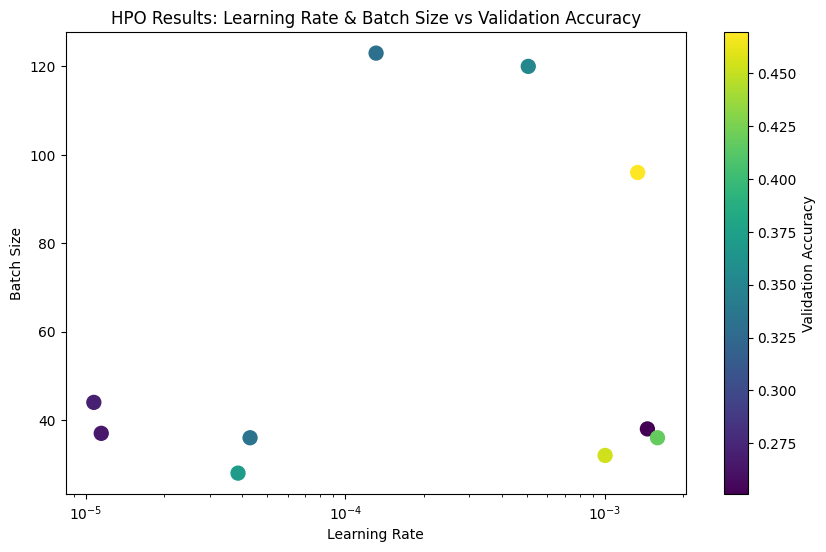

In [ ]:
# Take learning rates from all trials
lrs = [r["learning_rate"] for r in results]
# Take batch sizes from all trials
batches = [r["batch_size"] for r in results]
# Take validation accuracy from all trials
# color values
val_accs = [r["val_acc"] for r in results]

plt.figure(figsize=(10, 6))
# x = learning rate, y = batch size, color = validation accuracy
scatter = plt.scatter(lrs, batches, c=val_accs, cmap="viridis", s=100)
# Use logarithmic scale for learning rate
plt.xscale("log")
# Show color meaning
plt.colorbar(scatter, label="Validation Accuracy")
# Label the axes
plt.xlabel("Learning Rate")
plt.ylabel("Batch Size")
#title for the graph
plt.title("HPO Results: Learning Rate & Batch Size vs Validation Accuracy")
plt.show()

## full train

### BEST HYPERPARAMETERS


In [ ]:
# Take the best learning rate from hyperparameter tuning
# Learning rate controls how fast the model updates its weight
BEST_LR = best_config["learning_rate"]
# Take the best batch size from hyperparameter tuning
# Batch size is how many images we process at once during training
BEST_BATCH_SIZE = best_config["batch_size"]
# Number of times the full dataset will be trained
# Each pass through all images is called an epoch
EPOCHS = 25


### DATA LOADERS


In [ ]:
# Load training dataset in batches and shuffle images
# Shuffling ensures the model does not learn patterns from the order
train_loader = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True)
# Load validation dataset in batchesize and no shuffling
# Validation data is used to check model performance
val_loader   = DataLoader(val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)
# Load test dataset in batchesize and no shuffling
# Test dataset can be used for final evaluation
test_loader   = DataLoader(val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)



### Model Setup

In [ ]:
# Create CNN model for blood cell classification
# num_classes = total number of cell types
model = BloodCellCNN(num_classes).to(device)
# Loss function is measures how wrong the predictions are
# CrossEntropyLoss is used for classification
criterion = nn.CrossEntropyLoss()
# Adam optimizer is commonly used for faster convergence
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)

### TRAINING LOOP

In [ ]:

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
   # Lists to store losses and accuracies
    train_losses, val_losses = [], []
    train_acc_list, val_acc_list = [], []
 # Loop over each epoch
    for epoch in range(epochs):
              # Training
        model.train() # set model to training mode
        running_loss = 0  # total training loss for this epoch
        correct_train, total_train = 0, 0  # counters for training accuracy
 # Loop over all batches of training data
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)# move data to device

            optimizer.zero_grad() # clear previous gradients
            outputs = model(images)# get predictions
            loss = criterion(outputs, labels)# calculate the  loss
            loss.backward()# calculate the  gradients
            optimizer.step() # update model weights

            running_loss += loss.item() # add batch loss to total
              # calculate training accuracy
            _, predicted = torch.max(outputs, 1)# get class with highest probability
            correct_train += (predicted == labels).sum().item()# count correct predictions
            total_train += labels.size(0) # total images seen
# Training accuracy
#Train Accuracy = (Correct Predictions / Total Images) * 100

        train_acc = 100 * correct_train / total_train

        #  VALIDATION
        model.eval()  # set model to evaluation mode
        val_loss = 0
        correct_val, total_val = 0, 0# counters for validation accuracy
 # Disable gradient calculation for validation
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)# move data to device
                outputs = model(images)   # forward pass
                loss = criterion(outputs, labels) # calculate loss
                val_loss += loss.item()# add to total validation loss

                # calculate validation accuracy
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
 # Validation accuracy
 #Val Accuracy = (Correct Predictions / Total Validation Images) * 100
        val_acc = 100 * correct_val / total_val

        # Store metrics for plotting
        train_losses.append(running_loss / len(train_loader))# average train loss
        val_losses.append(val_loss / len(val_loader)) # average validation loss
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
  # Print epoch summary
        print(
            f"\nEpoch {epoch+1}: "
            f"Train Loss={train_losses[-1]:.4f}, "
            f"Train Acc={train_acc:.2f}%, "
            f"Val Loss={val_losses[-1]:.4f}, "
            f"Val Acc={val_acc:.2f}%\n"
        )
    # Return all metrics

    return train_losses, val_losses, train_acc_list, val_acc_list

### START TRAINING

In [ ]:
# Call the training function
# This actually runs the model learning process
train_losses, val_losses, train_acc_list, val_acc_list = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, epochs=EPOCHS
)



Epoch 1/25: 100%|██████████| 17/17 [01:29<00:00,  5.26s/it]



Epoch 1: Train Loss=1.3892, Train Acc=26.30%, Val Loss=1.3836, Val Acc=26.55%



Epoch 2/25: 100%|██████████| 17/17 [01:27<00:00,  5.16s/it]



Epoch 2: Train Loss=1.3697, Train Acc=30.38%, Val Loss=1.3252, Val Acc=36.15%



Epoch 3/25: 100%|██████████| 17/17 [01:27<00:00,  5.16s/it]


...


Epoch 23: Train Loss=0.0349, Train Acc=98.87%, Val Loss=1.1869, Val Acc=74.61%



Epoch 24/25: 100%|██████████| 17/17 [01:27<00:00,  5.16s/it]



Epoch 24: Train Loss=0.0423, Train Acc=98.56%, Val Loss=1.1710, Val Acc=72.70%



Epoch 25/25: 100%|██████████| 17/17 [01:27<00:00,  5.15s/it]



Epoch 25: Train Loss=0.0370, Train Acc=98.49%, Val Loss=1.1351, Val Acc=74.16%



## Graph

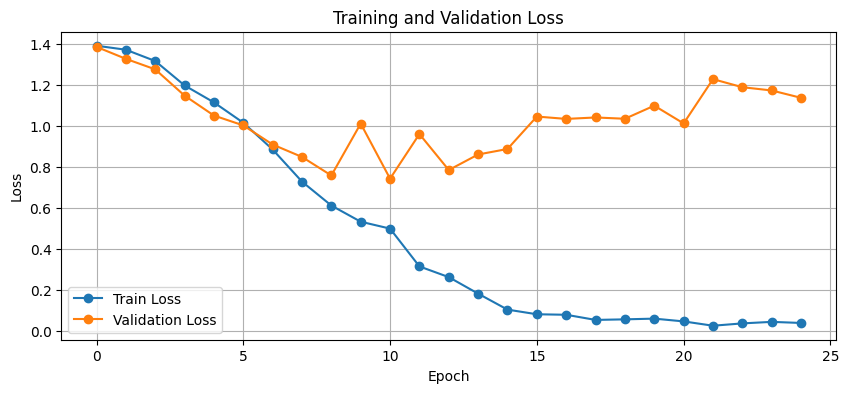

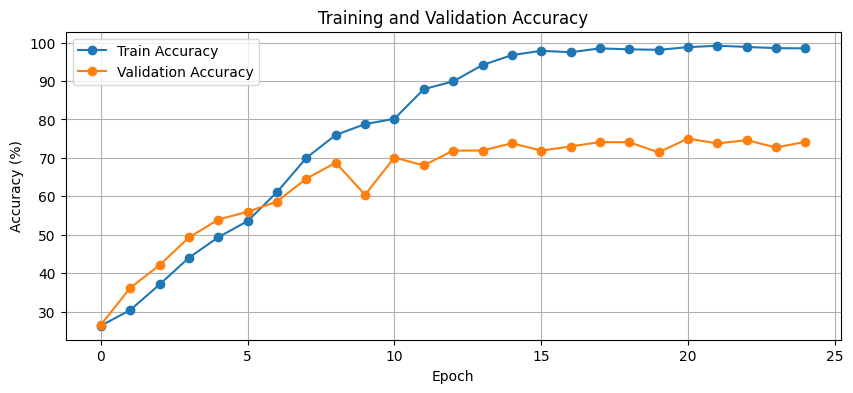

In [ ]:

# Loss Graph
plt.figure(figsize=(10,4)) # width = 10, height = 4
# Plot training loss values
plt.plot(train_losses, label="Train Loss", marker='o')
# x-axis = epochs
#y-axis = loss during training
# Plot validation loss values
plt.plot(val_losses, label="Validation Loss", marker='o')
# Add title and labels
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
# Show legen
plt.legend()
# Show grid for better reading
plt.grid(True)
# Display the graph
plt.show()

# Accuracy Graph
plt.figure(figsize=(10,4))  # width = 10, height = 4
# Plot training accuracy values
plt.plot(train_acc_list, label="Train Accuracy", marker='o')
# Plot validation accuracy values
# Add title and labels
plt.plot(val_acc_list, label="Validation Accuracy", marker='o')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
# Show legend
plt.legend()
# Show grid
plt.grid(True)
# Display the graph
plt.show()


## confusion matrix

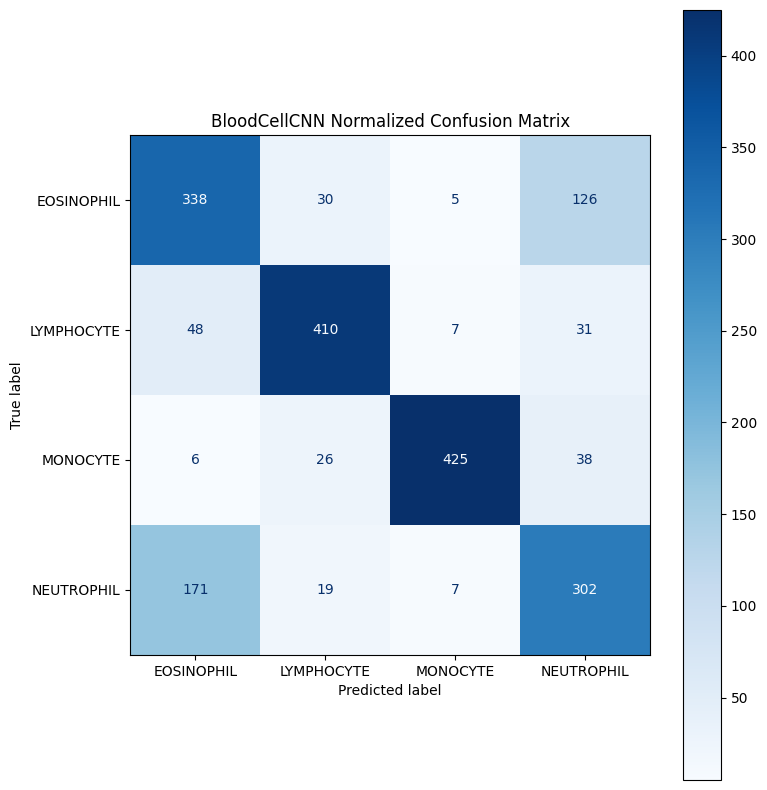

In [ ]:



def plot_confusion_matrix(model, data_loader, class_names, device):
    model.eval() # set model to evaluation mode

    all_preds = [] # store predicted labels
    all_labels = [] # store true labels
# Turn off gradient calculatio
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)  # move images to CPU
            labels = labels.to(device) # move labels to CPU

            outputs = model(images) # model makes predictions
            preds = torch.argmax(outputs, dim=1) # get class with highest score

            all_preds.append(preds.cpu().numpy())  # save predictions
            all_labels.append(labels.cpu().numpy())# save true labels
  # Combine all batches into one array
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    # Create confusion matrix

    # Rows = actual class, Columns = predicted class
    cm = confusion_matrix(all_labels, all_preds)
  # Create display object for plotting
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
 # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    plt.title("BloodCellCNN Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    model, # trained model
    test_loader,   # test dataset loader
    train_dataset.dataset.classes,  # class names
    device  # CPU/GPU
)


## evaluate metrics

Class          Precision (%)  Recall (%)     F1 (%)    Support   
----------------------------------------------------------------------
EOSINOPHIL     60.04          67.74          63.65     499       
LYMPHOCYTE     84.54          82.66          83.59     496       
MONOCYTE       95.72          85.86          90.52     495       
NEUTROPHIL     60.76          60.52          60.64     499       

Overall Accuracy: 74.16%



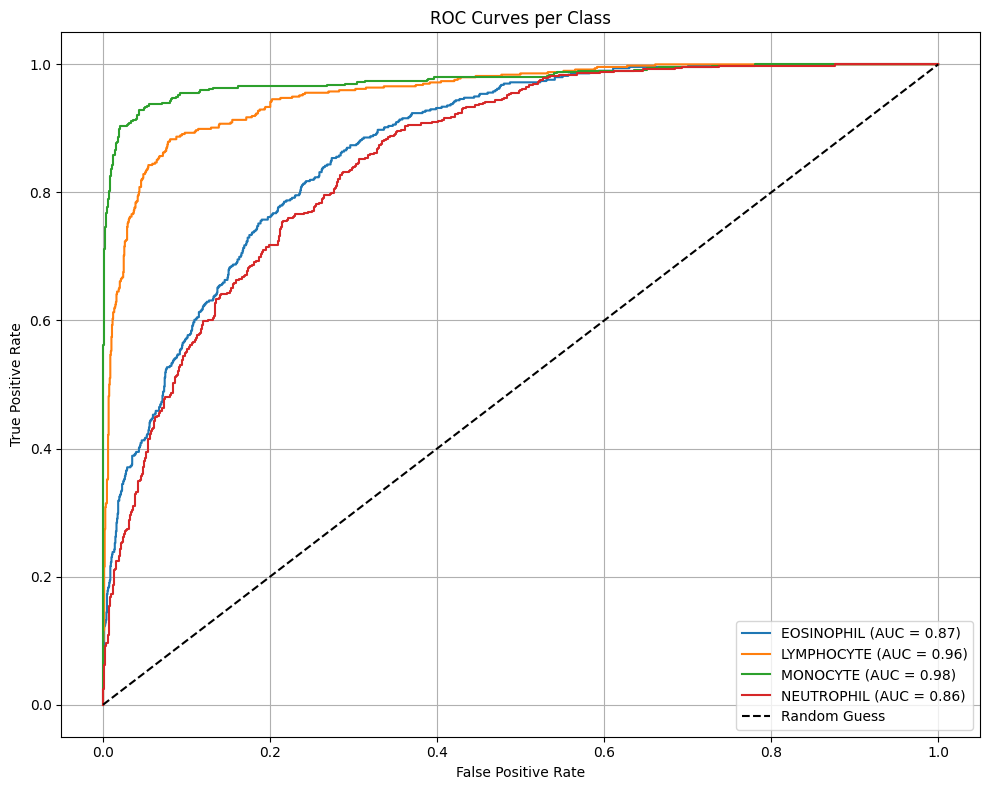

In [ ]:


def evaluate_model(model, test_loader, classes, device):

    model.eval()  # set model to evaluation mode

    all_labels = []  # store true labels
    all_preds = []  # store predicted labels
    all_probs = [] # store prediction probabilities

    # Disable gradient  for evaluation
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  # move images to device
            labels = labels.to(device)

            outputs = model(images)   # model predicts scores
            probs = F.softmax(outputs, dim=1) # convert scores to probabilities
            preds = torch.argmax(outputs, dim=1)   # predicted class
 # Combine all batches into one array
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Combine all batches
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)

      # Precision = correct_predictions / all_predicted_as_this_class
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0) * 100
    # Recall = correct_predictions / all_actual_this_class
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0) * 100
     # F1-score = 2 * (Precision * Recall) / (Precision + Recall)
    f1 = f1_score(all_labels, all_preds, average=None, zero_division=0) * 100
      # Support = number of true samples per class
    support = [(all_labels == i).sum() for i in range(len(classes))]
 # Print table header
    print(f"{'Class':<15}{'Precision (%)':<15}{'Recall (%)':<15}{'F1 (%)':<10}{'Support':<10}")
    print("-" * 70)
      # Print metrics for each class
    for i, class_name in enumerate(classes):
        print(f"{class_name:<15}{precision[i]:<15.2f}{recall[i]:<15.2f}{f1[i]:<10.2f}{support[i]:<10}")

    # Accuracy = (Correct Predictions / Total Predictions) * 100

    overall_acc = (all_labels == all_preds).mean() * 100
    print(f"\nOverall Accuracy: {overall_acc:.2f}%\n")


    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(classes):
      # True labels for this class
        y_true = (all_labels == i).astype(int)
        if y_true.sum() == 0:
            continue
              # calculate ROC curve values
        fpr, tpr, _ = roc_curve(y_true, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        # Plot ROC curve
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
 # Random classifier line
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.title("ROC Curves per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs
# Run evaluation on test data


all_labels, all_preds, all_probs = evaluate_model(
    model, test_loader, classes, device
)

# resnet50

## hyperparameter


### HPO Objective

In [ ]:


def hpo_objectiveRN50(BEST_LR, BEST_BATCH_SIZE, epochs=5):

    #  MODEL
    # Load pre-trained ResNet50 model with weights trained on ImageNet
    modelRN50 = models.resnet50(weights="IMAGENET1K_V1")
    # Replace the final fully-connected layer to match our number of classes
    #formule is  new_fc = Linear(old_fc_in_features, num_classes)
    modelRN50.fc = nn.Linear(modelRN50.fc.in_features, num_classes)
    # Move model to device
    modelRN50 = modelRN50.to(device)
# Loss function is cross-entropy for multi-class classification
    criterionRN50 = nn.CrossEntropyLoss()
    # Optimizer Adam updates model weights using best learning rate
    optimizerRN50 = optim.Adam(modelRN50.parameters(), lr=BEST_LR)
# Training data loaderis loads data in batches, shuffles for randomn
    train_loader = DataLoader(
        train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True
    )
    #Validation data loader is loads data in batches, no shuffle
    val_loader = DataLoader(
        val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False
    )

    best_val_acc = 0.0  # store the best validation accuracy so far

    for epoch in range(epochs):
        # TRAINING
        modelRN50.train()
        correct_train, total_train = 0, 0

        for images, labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}"
        ):
            images, labels = images.to(device), labels.to(device)

            optimizerRN50.zero_grad()
            outputs = modelRN50(images)
            loss = criterionRN50(outputs, labels)
            loss.backward()
            optimizerRN50.step()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train

        #  VALIDATION
        modelRN50.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = modelRN50(images)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        best_val_acc = max(best_val_acc, val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc*100:.2f}% | "
            f"Val Acc={val_acc*100:.2f}%"
        )

    return best_val_acc, train_acc


### Random Searcher

In [ ]:

class RandomSearcherRN50:
    def __init__(self, config_space, initial_config=None):
        self.config_space = config_space
        self.initial_config = initial_config

    def sample(self):
        if self.initial_config is not None:
            cfg = self.initial_config
            self.initial_config = None
            return cfg
        return {k: v.rvs() for k, v in self.config_space.items()}


### Search Space

In [ ]:

config_spaceRN50 = {
    "BEST_LR": stats.loguniform(1e-5, 1e-3),
    "BEST_BATCH_SIZE": stats.randint(16, 64),
}

initial_configRN50 = {
    "BEST_LR": 1e-4,
    "BEST_BATCH_SIZE": 32
}

searcherRN50 = RandomSearcherRN50(
    config_spaceRN50, initial_configRN50
)


### Run Hyperparameter

In [ ]:



best_configRN50 = None
best_val_accRN50 = 0.0
resultsRN50 = []

num_trials = 10  # Increase to 10

for i in range(num_trials):
    config = searcherRN50.sample()
    print(f"\nTrial {i+1}/{num_trials} → {config}")

    start = time.time()
    val_acc, train_acc = hpo_objectiveRN50(**config, epochs= 5)
    runtime = time.time() - start

    print(
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Time: {runtime:.1f}s"
    )
 #
    #  STORE RESULTS FOR PLOTTING
    resultsRN50.append({
        #
        "learning_rate": config["BEST_LR"],
        "batch_size": config["BEST_BATCH_SIZE"],
        "val_acc": val_acc
    })
#
    if val_acc > best_val_accRN50:
        best_val_accRN50 = val_acc
        best_configRN50 = config


Trial 1/10 → {'BEST_LR': 0.0001, 'BEST_BATCH_SIZE': 32}
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]
Epoch 1/5: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]


Epoch 1: Train Acc=76.40% | Val Acc=93.46%


Epoch 2/5: 100%|██████████| 50/50 [00:13<00:00,  3.62it/s]


Epoch 2: Train Acc=98.18% | Val Acc=96.33%


...

Epoch 3: Train Acc=98.05% | Val Acc=93.97%


Epoch 4/5: 100%|██████████| 55/55 [00:12<00:00,  4.50it/s]


Epoch 4: Train Acc=97.80% | Val Acc=93.31%


Epoch 5/5: 100%|██████████| 55/55 [00:11<00:00,  4.60it/s]


Epoch 5: Train Acc=98.87% | Val Acc=96.03%
Train Acc: 98.87% | Val Acc: 96.03% | Time: 119.2s


### show Best Hyperparameters

In [ ]:





print("BEST RESNET-50 HYPERPARAMETERS")
print(best_configRN50)
print(f"Best Validation Accuracy: {best_val_accRN50*100:.2f}%")


BEST RESNET-50 HYPERPARAMETERS
{'BEST_LR': 0.0001, 'BEST_BATCH_SIZE': 32}
Best Validation Accuracy: 96.33%


## graph

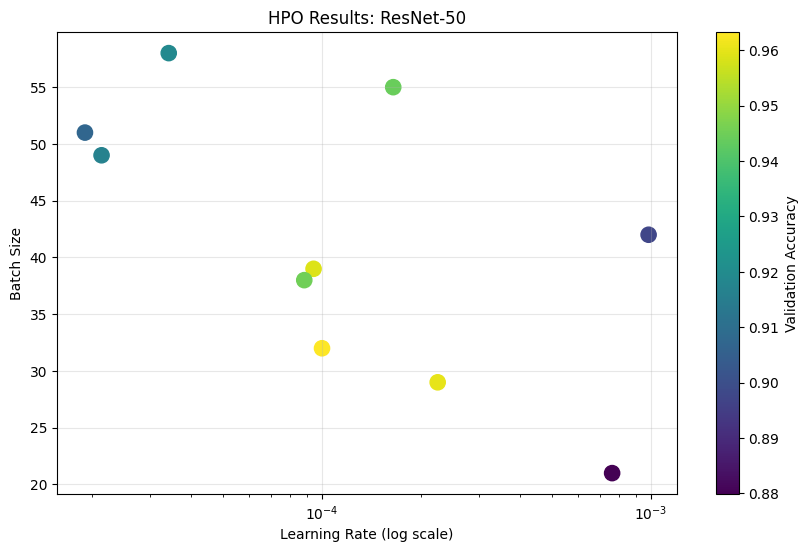

In [ ]:



lrs = [r["learning_rate"] for r in resultsRN50]
batches = [r["batch_size"] for r in resultsRN50]
val_accs = [r["val_acc"] for r in resultsRN50]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    lrs, batches,
    c=val_accs,
    cmap="viridis",
    s=120
)
plt.xscale("log")
plt.colorbar(scatter, label="Validation Accuracy")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Batch Size")
plt.title("HPO Results: ResNet-50")
plt.grid(True, alpha=0.3)
plt.show()


## MODEL

### BEST HYPERPARAMETERS


In [ ]:

BEST_LR = best_configRN50["BEST_LR"]
BEST_BATCH_SIZE = best_configRN50["BEST_BATCH_SIZE"]
EPOCHS = 25


### DATA LOADERS


In [ ]:

# Training data loader is loads images in batches and shuffles them
# shuffle is True to mixes images every epoch to help model
train_loader = DataLoader(
    train_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=True
)
# Validation data loader is loads images in batches, no shuffle
# shuffle is False to keep order consistent for evaluation
val_loader = DataLoader(
    val_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=False
)
# Test data loader is used to evaluate model on unseen test set
test_loader = DataLoader(
    test_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=False
)

### Model Setup

In [ ]:

# Load pre-trained ResNet50 model with weights trained on ImageNet
# This helps model learn faster

modelRN50 = models.resnet50(weights="IMAGENET1K_V1")

# Freeze backbone layers
# param.requires_grad=False doesn't update these weights during training

for param in modelRN50.parameters():
    param.requires_grad = False

# Replace final classifier to match our dataset
#formula is new_fc = Linear(old_fc_in_features, num_classes)
modelRN50.fc = nn.Linear(
    modelRN50.fc.in_features,# input features of last layer
    num_classes  # number of output classes
)

# Unfreeze only the classifier layer so it can learn
for param in modelRN50.fc.parameters():
    param.requires_grad = True
# Move model to CPU
modelRN50 = modelRN50.to(device)
# Loss function is cross-entropy for multi-class classification

criterionRN50 = nn.CrossEntropyLoss()
# Optimizer Adam updates weights of unfrozen layers using best learning rate
optimizerRN50 = optim.Adam(
    modelRN50.parameters(),# parameters to update
    lr=BEST_LR   # learning rate
)

### TRAINING LOOP

In [ ]:



def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses, val_losses = [], []
    train_acc_list, val_acc_list = [], []

    for epoch in range(epochs):
        #  TRAIN
        model.train()
        running_loss = 0
        correct_train, total_train = 0, 0

        for images, labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}"
        ):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = 100 * correct_train / total_train

        #  VALIDATION
        model.eval()
        val_loss = 0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_acc = 100 * correct_val / total_val

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(
            f"\nEpoch {epoch+1}: "
            f"Train Loss={train_losses[-1]:.4f}, "
            f"Train Acc={train_acc:.2f}%, "
            f"Val Loss={val_losses[-1]:.4f}, "
            f"Val Acc={val_acc:.2f}%\n"
        )

    return train_losses, val_losses, train_acc_list, val_acc_list



### START TRAINING

In [ ]:


train_losses_RN50, val_losses_RN50, train_acc_RN50, val_acc_RN50 = train_model(
    modelRN50,
    train_loader,
    val_loader,
    criterionRN50,
    optimizerRN50,
    epochs=EPOCHS
)



Epoch 1/25: 100%|██████████| 50/50 [00:09<00:00,  5.34it/s]



Epoch 1: Train Loss=1.3806, Train Acc=29.19%, Val Loss=1.3394, Val Acc=35.39%



Epoch 2/25: 100%|██████████| 50/50 [00:09<00:00,  5.33it/s]



Epoch 2: Train Loss=1.3068, Train Acc=38.86%, Val Loss=1.2826, Val Acc=43.99%



Epoch 3/25: 100%|██████████| 50/50 [00:09<00:00,  5.06it/s]


...


Epoch 23: Train Loss=0.8366, Train Acc=70.75%, Val Loss=0.9190, Val Acc=65.06%



Epoch 24/25: 100%|██████████| 50/50 [00:09<00:00,  5.26it/s]



Epoch 24: Train Loss=0.8261, Train Acc=71.56%, Val Loss=0.9078, Val Acc=63.95%



Epoch 25/25: 100%|██████████| 50/50 [00:09<00:00,  5.27it/s]



Epoch 25: Train Loss=0.8064, Train Acc=71.00%, Val Loss=0.9089, Val Acc=64.81%



## graph

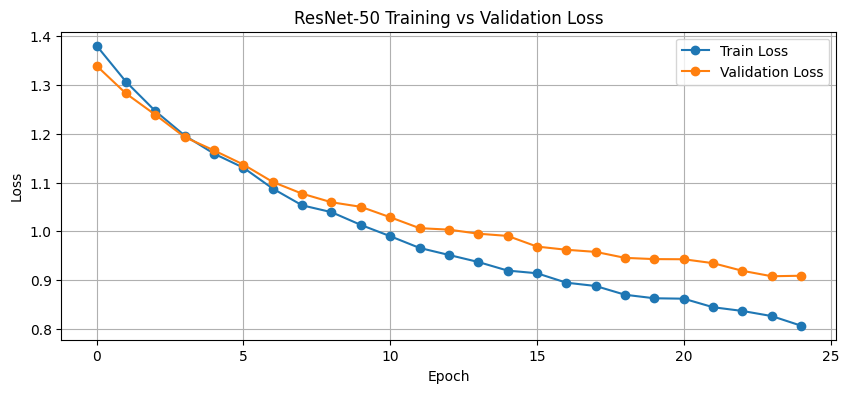

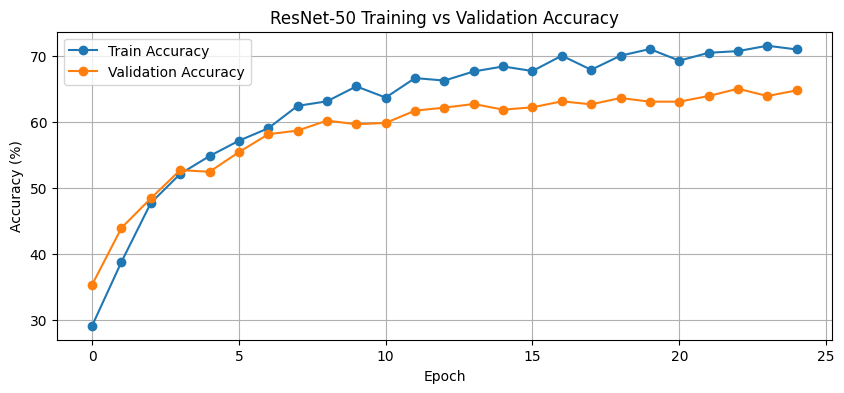

In [ ]:

plt.figure(figsize=(10,4))
plt.plot(train_losses_RN50, label="Train Loss", marker='o')
plt.plot(val_losses_RN50, label="Validation Loss", marker='o')
plt.title("ResNet-50 Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.plot(train_acc_RN50, label="Train Accuracy", marker='o')
plt.plot(val_acc_RN50, label="Validation Accuracy", marker='o')
plt.title("ResNet-50 Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


## CONFUSION MATRIX

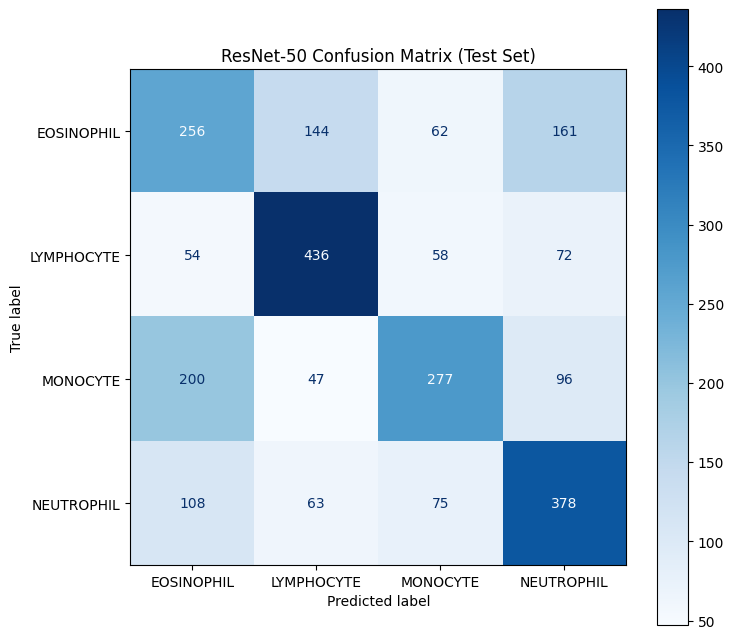

In [ ]:

def plot_confusion_matrix(model, data_loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    plt.title("ResNet-50 Confusion Matrix (Test Set)")
    plt.show()

# Call it
plot_confusion_matrix(
    modelRN50,
    test_loader,
    train_dataset.dataset.classes,
)


## eval

Class          Precision Recall    F1        Support   
-------------------------------------------------------
EOSINOPHIL     0.4142    0.4109    0.4126    623       
LYMPHOCYTE     0.6319    0.7032    0.6656    620       
MONOCYTE       0.5869    0.4468    0.5073    620       
NEUTROPHIL     0.5347    0.6058    0.5680    624       

Overall Accuracy: 54.16%



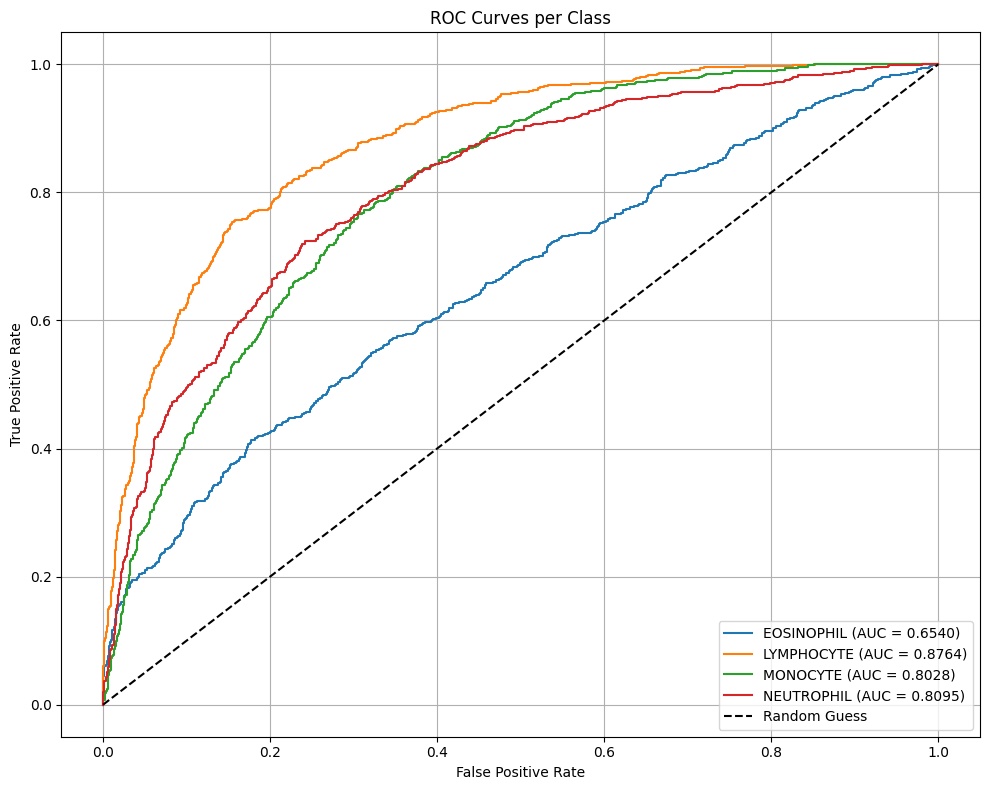

In [ ]:


def evaluate_model(modelRN50, test_loader, classes, device):

    modelRN50.eval()  # set model to evaluation mode

    all_labels = []
    all_preds = []
    all_probs = []

    # Disable gradient computation for evaluation
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = modelRN50(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Combine all batches
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)

    #  Per-class metrics: Precision, Recall, F1, Support
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    support = [(all_labels == i).sum() for i in range(len(classes))]

    # Print neatly in table format
    print(f"{'Class':<15}{'Precision':<10}{'Recall':<10}{'F1':<10}{'Support':<10}")
    print("-" * 55)
    for i, class_name in enumerate(classes):
        print(f"{class_name:<15}{precision[i]:<10.4f}{recall[i]:<10.4f}{f1[i]:<10.4f}{support[i]:<10}")

    # Overall accuracy
    overall_acc = (all_labels == all_preds).mean()
    print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%\n")

    #  ROC Curves per class
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(classes):
        y_true = (all_labels == i).astype(int)
        if y_true.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.title("ROC Curves per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs



all_labels, all_preds, all_probs = evaluate_model(
    modelRN50, test_loader, classes, device
)


# EB3

## Hyperparameter

### HPO Objective

In [ ]:



def hpo_objectiveEB3(BEST_LR, BEST_BATCH_SIZE, epochs=1):

    #  MODEL
    # Load pre-trained EfficientNet-B3 model with ImageNet weights
    # This helps the model learn faster
    modelEB3 = efficientnet_b3(
        weights=EfficientNet_B3_Weights.IMAGENET1K_V1
    )
# Replace the classifier layer
# so the output matches the number of classes in our dataset
    modelEB3.classifier[1] = nn.Linear(
        modelEB3.classifier[1].in_features,# input features of the classifier
        num_classes # number of output classes
    )
# Move model to device
    modelEB3 = modelEB3.to(device)
# Loss function is cross-entropy for multi-class classification
# Optimizer Adam updates model weights using the best learning rate
    criterionEB3 = nn.CrossEntropyLoss()# parameters to train
    # learning rate
    optimizerEB3 = optim.Adam(modelEB3.parameters(), lr=BEST_LR)

    train_loader = DataLoader(
        train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False
    )

    best_val_acc = 0.0  # store the highest validation accuracy achieved

    for epoch in range(epochs):
        #  TRAIN
        modelEB3.train()
        correct_train, total_train = 0, 0

        for images, labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}"
        ):
            images, labels = images.to(device), labels.to(device)

            optimizerEB3.zero_grad()
            outputs = modelEB3(images)
            loss = criterionEB3(outputs, labels)
            loss.backward()
            optimizerEB3.step()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train

        #  VALIDATION
        modelEB3.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = modelEB3(images)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        best_val_acc = max(best_val_acc, val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc*100:.2f}% | "
            f"Val Acc={val_acc*100:.2f}%"
        )

    return best_val_acc, train_acc

### Random Searcher

In [ ]:

class RandomSearcherEB3:
    def __init__(self, config_space, initial_config=None):
        self.config_space = config_space
        self.initial_config = initial_config

    def sample(self):
        if self.initial_config is not None:
            cfg = self.initial_config
            self.initial_config = None
            return cfg
        return {k: v.rvs() for k, v in self.config_space.items()}


### Search Space

In [ ]:



config_spaceEB3 = {
    "BEST_LR": stats.loguniform(1e-5, 1e-3),
    "BEST_BATCH_SIZE": stats.randint(16, 64),
}

initial_configEB3 = {
    "BEST_LR": 1e-4,
    "BEST_BATCH_SIZE": 32
}

searcherEB3 = RandomSearcherEB3(
    config_spaceEB3, initial_configEB3
)


### Run Hyperparameter

In [ ]:



best_configEB3 = None
best_val_accEB3 = 0.0

num_trials = 10  # Increase to 10
resultsEB3 = []

for i in range(num_trials):
    config = searcherEB3.sample()
    print(f"\nTrial {i+1}/{num_trials} → {config}")

    start = time.time()
    val_acc, train_acc = hpo_objectiveEB3(**config, epochs=5)
    runtime = time.time() - start

    print(
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Time: {runtime:.1f}s"
    )


    resultsEB3.append({
        "learning_rate": config["BEST_LR"],
        "batch_size": config["BEST_BATCH_SIZE"],
        "val_acc": val_acc
    })

    if val_acc > best_val_accEB3:
        best_val_accEB3 = val_acc
        best_configEB3 = config


Trial 1/10 → {'BEST_LR': 0.0001, 'BEST_BATCH_SIZE': 32}
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 195MB/s]
Epoch 1/5: 100%|██████████| 50/50 [00:13<00:00,  3.80it/s]


Epoch 1: Train Acc=40.11% | Val Acc=57.77%


Epoch 2/5: 100%|██████████| 50/50 [00:12<00:00,  3.98it/s]


Epoch 2: Train Acc=71.50% | Val Acc=79.03%


...

Epoch 3: Train Acc=97.36% | Val Acc=96.83%


Epoch 4/5: 100%|██████████| 57/57 [00:12<00:00,  4.52it/s]


Epoch 4: Train Acc=98.87% | Val Acc=97.39%


Epoch 5/5: 100%|██████████| 57/57 [00:12<00:00,  4.54it/s]


Epoch 5: Train Acc=98.68% | Val Acc=97.08%
Train Acc: 98.68% | Val Acc: 97.39% | Time: 118.0s


### show Best Hyperparameters

In [ ]:




print("BEST EFFICIENTNET-B3 HYPERPARAMETERS")
print(best_configEB3)
print(f"Best Validation Accuracy: {best_val_accEB3*100:.2f}%")


BEST EFFICIENTNET-B3 HYPERPARAMETERS
{'BEST_LR': np.float64(0.00023765847999162974), 'BEST_BATCH_SIZE': 28}
Best Validation Accuracy: 97.39%


## graph

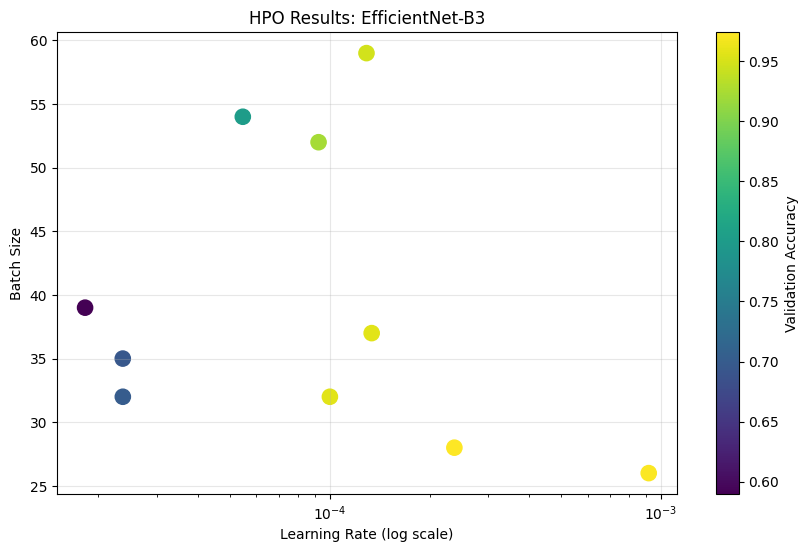

In [ ]:


lrs = [r["learning_rate"] for r in resultsEB3]
batches = [r["batch_size"] for r in resultsEB3]
val_accs = [r["val_acc"] for r in resultsEB3]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    lrs,
    batches,
    c=val_accs,
    cmap="viridis",
    s=120
)
plt.xscale("log")
plt.colorbar(scatter, label="Validation Accuracy")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Batch Size")
plt.title("HPO Results: EfficientNet-B3")
plt.grid(True, alpha=0.3)
plt.show()


## Train

### BEST HYPERPARAMETERS


In [ ]:

BEST_LR = best_configEB3["BEST_LR"]
BEST_BATCH_SIZE = best_configEB3["BEST_BATCH_SIZE"]
EPOCHS = 25



### DATA LOADERS


In [ ]:

train_loader = DataLoader(
    train_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    val_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=False
)




NameError: name 'train_dataset' is not defined

### Model Setup

In [ ]:
   # Load pre-trained EfficientNet-B3 model with ImageNet weights
    # This helps the model learn faster
modelEB3 = efficientnet_b3(
    weights=EfficientNet_B3_Weights.IMAGENET1K_V1
)

# Replace the classifier layer
# so the output matches the number of classes in our dataset
modelEB3.classifier[1] = nn.Linear(
    modelEB3.classifier[1].in_features,# input features of the classifier
    num_classes# number of output classes
)
# Move model to device
modelEB3 = modelEB3.to(device)
# Loss function is cross-entropy for multi-class classification
# Optimizer Adam updates model weights using the best learning rate
criterionEB3 = nn.CrossEntropyLoss()# parameters to train
# learning rate
optimizerEB3 = optim.Adam(modelEB3.parameters(), lr=BEST_LR)

### TRAINING LOOP

In [ ]:

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses, val_losses = [], []
    train_acc_list, val_acc_list = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct_train, total_train = 0, 0

        for images, labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}"
        ):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = 100 * correct_train / total_train

        #  VALIDATION
        model.eval()
        val_loss = 0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_acc = 100 * correct_val / total_val

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(
            f"\nEpoch {epoch+1}: "
            f"Train Loss={train_losses[-1]:.4f}, "
            f"Train Acc={train_acc:.2f}%, "
            f"Val Loss={val_losses[-1]:.4f}, "
            f"Val Acc={val_acc:.2f}%\n"
        )

    return train_losses, val_losses, train_acc_list, val_acc_list


### START TRAINING

In [ ]:



train_losses_EB3, val_losses_EB3, train_acc_EB3, val_acc_EB3 = train_model(
    modelEB3,
    train_loader,
    val_loader,
    criterionEB3,
    optimizerEB3,
    epochs=EPOCHS
)

## graph

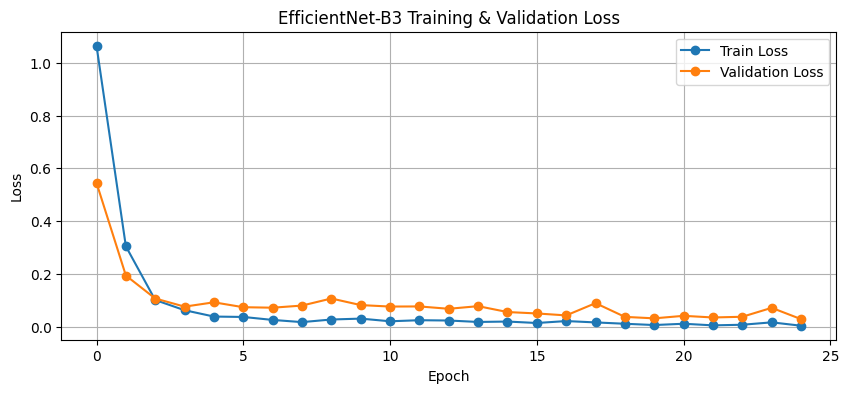

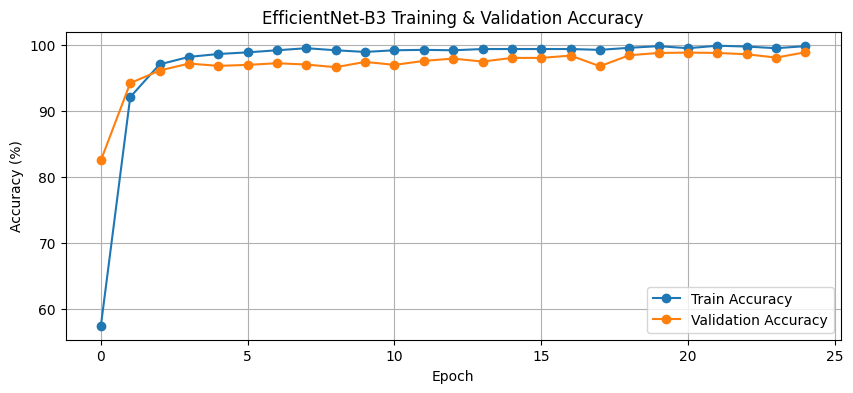

In [ ]:

#  LOSS
plt.figure(figsize=(10,4))
plt.plot(train_losses_EB3, label="Train Loss", marker='o')
plt.plot(val_losses_EB3, label="Validation Loss", marker='o')
plt.title("EfficientNet-B3 Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#  ACCURACY
plt.figure(figsize=(10,4))
plt.plot(train_acc_EB3, label="Train Accuracy", marker='o')
plt.plot(val_acc_EB3, label="Validation Accuracy", marker='o')
plt.title("EfficientNet-B3 Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


## CONFUSION MATRIX

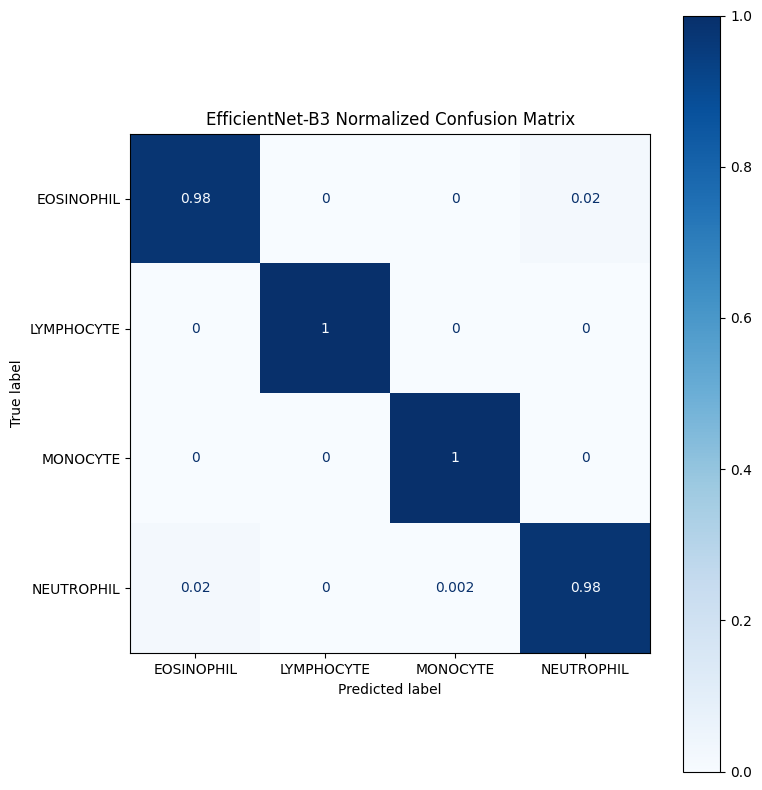

In [ ]:


def plot_confusion_matrix(modelEB3, data_loader, class_names, device):
    modelEB3.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = modelEB3(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    cm = confusion_matrix(all_labels, all_preds, normalize="true")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    plt.title("EfficientNet-B3 Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()



plot_confusion_matrix(
    modelEB3,
    test_loader,
    train_dataset.dataset.classes,
    device
)


## eval

Class          Precision Recall    F1        Support   
-------------------------------------------------------
EOSINOPHIL     0.9800    0.9800    0.9800    499       
LYMPHOCYTE     1.0000    1.0000    1.0000    496       
MONOCYTE       0.9980    1.0000    0.9990    495       
NEUTROPHIL     0.9799    0.9780    0.9789    499       

Overall Accuracy: 98.94%



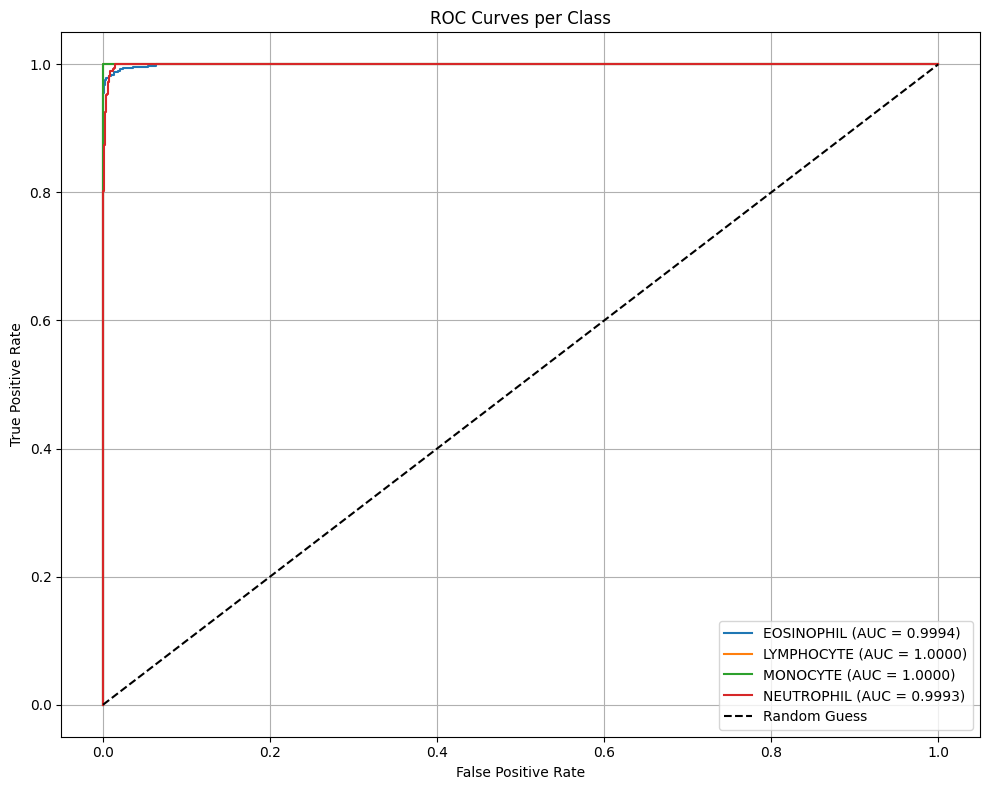

In [ ]:


def evaluate_model(modelEB3, test_loader, classes, device):

    modelEB3.eval()  # set model to evaluation mode

    all_labels = []
    all_preds = []
    all_probs = []

    # Disable gradient computation for evaluation
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = modelEB3(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Combine all batches
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)

    #  Per-class metrics: Precision, Recall, F1, Support
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    support = [(all_labels == i).sum() for i in range(len(classes))]

    # Print neatly in table format
    print(f"{'Class':<15}{'Precision':<10}{'Recall':<10}{'F1':<10}{'Support':<10}")
    print("-" * 55)
    for i, class_name in enumerate(classes):
        print(f"{class_name:<15}{precision[i]:<10.4f}{recall[i]:<10.4f}{f1[i]:<10.4f}{support[i]:<10}")

    # Overall accuracy
    overall_acc = (all_labels == all_preds).mean()
    print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%\n")

    # ROC Curves per class
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(classes):
        y_true = (all_labels == i).astype(int)
        if y_true.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.title("ROC Curves per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs



all_labels, all_preds, all_probs = evaluate_model(
    modelEB3, test_loader, classes, device
)
